## Review on basic Python data visualziation and data summary 

### Goal for today： 

- Review on basic data structure
- Understand basic rules to choose figure type
- Learn how to describe data and simple figures 
- Review basic plotting options in Python (matplotlib and seaborn)
- Visualization with modeling (optional)


### Describing a data set

In a data table (also called ``data matrix"), like the one below. There are two dimensions in the data: 

- Observations: each individual subject, case, or sample point (rows, represented with $n$)
- Variables/Feature: characteristics that are recorded for each subject in the sample (columns, represented with $p$)


In [6]:
#pip install pandas seaborn matplotlib

In [7]:
import pandas as pd

df = pd.read_csv("ICUAdmissions.csv")
df['Status'] = df['Status'].map({0: 'survived', 1: 'dead'})
print(df.head())

   ID    Status  Age  Sex  Race  Service  Cancer  Renal  Infection  CPR  ...  \
0   8  survived   27    1     1        0       0      0          1    0  ...   
1  12  survived   59    0     1        0       0      0          0    0  ...   
2  14  survived   77    0     1        1       0      0          0    0  ...   
3  28  survived   54    0     1        0       0      0          1    0  ...   
4  32  survived   87    1     1        1       0      0          1    0  ...   

   HeartRate  Previous  Type  Fracture  PO2  PH  PCO2  Bicarbonate  \
0         88         0     1         0    0   0     0            0   
1         80         1     1         0    0   0     0            0   
2         70         0     0         0    0   0     0            0   
3        103         0     1         1    0   0     0            0   
4        154         1     1         0    0   0     0            0   

   Creatinine  Consciousness  
0           0              1  
1           0              1  
2    

### Describing variables

There are at least two ways to describe variables:
		
By value type:
		
- Numerical variables: take on numerical values with meaning Mathematical operations like addition, etc. must make sense
- Categorical variables: take on names, categories, or labels Categories are sometimes represented by numbers...

By function:
		
- Response variable/Target: defined by the particular research question a study seeks to address, and measures the outcome of interest in the study
- Explanatory variable/Feature: a secondary variable(s) that explains changes in the response variable

### Important terminology clarification

- feature
- variable
- attribute

### In-class activities

Suppose my research question is "What factors may be related to the heart rate in ICU admissions?" Try to make three data viasualizations. 

Things you need to decide: 
- What features I want to choose for the data visualizaiton?
- What type of figures I will choose? 
- What information I want to achieve from the data visualization?
- ......

Put your answers in 
https://docs.google.com/document/d/1Ve_gSHDO2Avxt8GDmsFumbIfPgMH8BYa4zvukRQJSXk/edit?usp=sharing


In [4]:
# Example 1: 

In [5]:
# Example 2: 

In [6]:
# Example 3: 

### Basic data visualization choices

Here is a general guidline for the type of plots: 

- One categorical: bar plot
- One numerical: histogram/density plot/boxplot
- Two numerical: scatter plot
- One categorical and one numerical: side-by-side boxplot
- Two categorical: side-by-side bar plot 

#### One categorical: bar plot

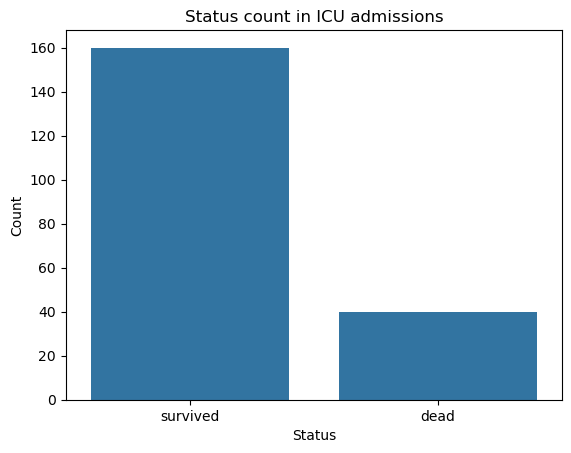

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Status', data=df)
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('Status count in ICU admissions')
status_counts = df['Status'].value_counts()
plt.show()

In [18]:
print(status_counts)

Status
survived    160
dead         40
Name: count, dtype: int64


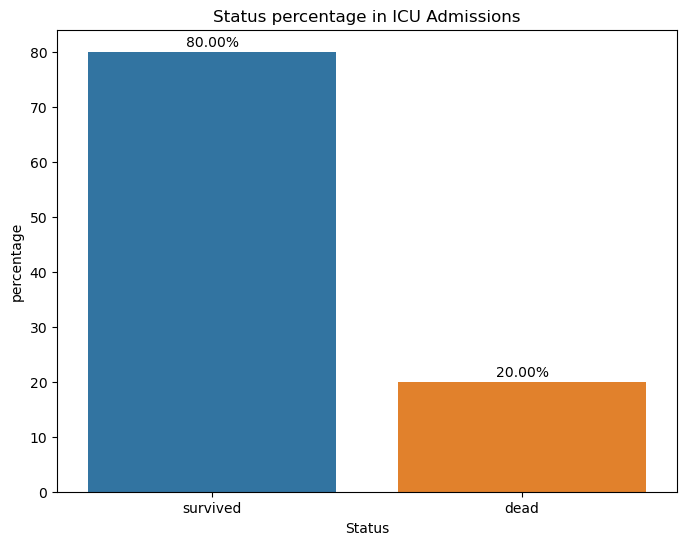

In [8]:
status_counts = df['Status'].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 6))
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.xlabel('Status')
plt.ylabel('percentage')
plt.title('Status percentage in ICU Admissions')

# Display the percentage values above the bars (optional)
for i, value in enumerate(status_counts.values):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center')
    
plt.show()

##### What to write about a bar plot

- What the plot is about? (which feature?)
- Percentage/Count for each group
- Whether there is a clear difference on the percentage/count (subjective)

EX: The figure is about the number of people survive in the ICU admissions. Status "0" means
the patient has survived in the ICU while status "1" means the patient died in the ICU. Among
the 200 patients in the data, there are 40 patients (40%) died in the ICU.

#### One numerical: histogram/density plot/boxplot

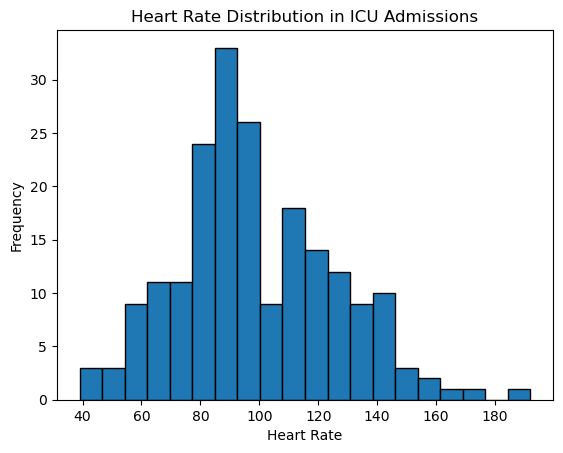

In [24]:
plt.hist(df['HeartRate'], bins=20, edgecolor='black')
# Set plot labels
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.title('Heart Rate Distribution in ICU Admissions')
# Show the plot
plt.show()

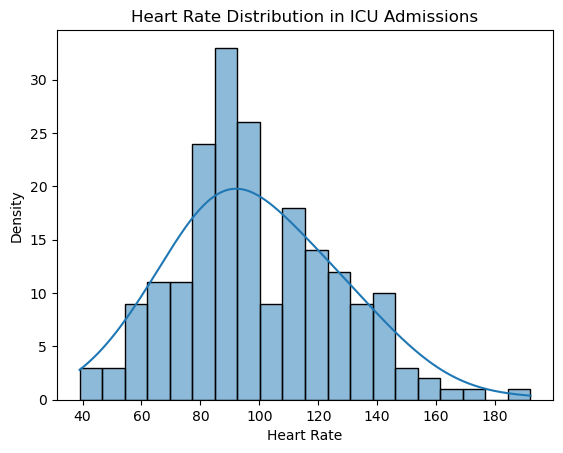

In [27]:
sns.histplot(df["HeartRate"], kde=True, bins=20, kde_kws={'bw_method': 0.6})
# Set plot labels
plt.xlabel('Heart Rate')
plt.ylabel('Density')
plt.title('Heart Rate Distribution in ICU Admissions')
# Show the plot
plt.show()

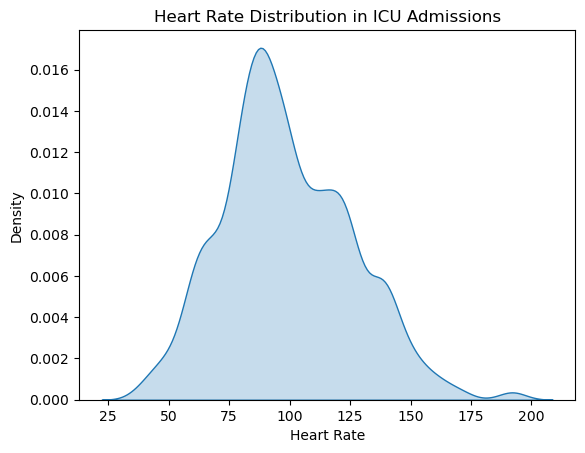

In [37]:
sns.kdeplot(df['HeartRate'], fill=True, bw_adjust=0.6)
# Set plot labels
plt.xlabel('Heart Rate')
plt.ylabel('Density')
plt.title('Heart Rate Distribution in ICU Admissions')
# Show the plot
plt.show()

Text(0.5, 1.0, 'heartrate box plot for ICU admissions')

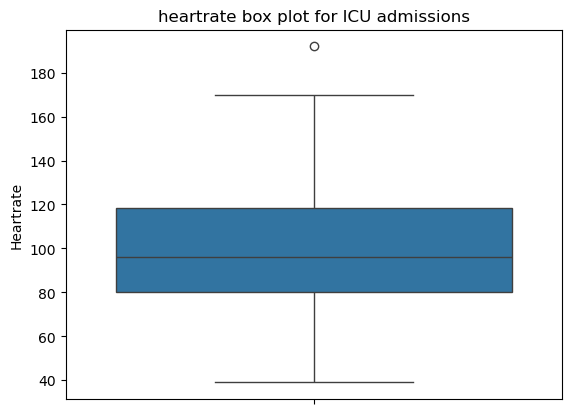

In [32]:
sns.boxplot(data = df , y ="HeartRate")
plt.ylabel('Heartrate')
plt.title("heartrate box plot for ICU admissions")
plt.show()

In [35]:
df['HeartRate'].describe()

count    200.00000
mean      98.92500
std       26.82962
min       39.00000
25%       80.00000
50%       96.00000
75%      118.25000
max      192.00000
Name: HeartRate, dtype: float64

##### Difference between histogram/density plot/ boxplot
- Histogram and density plot emphasizes on the distribution of the data (shape)
- Boxplot emphasizes on the statistics of the data (median, IQR)
- Boxplot cannot catch the distribution information, like bi-mode
- Histogram needs to choose the bin number and density plot needs to choose the bandwidthidth


##### Difference between histogram and bar plot
- histogram is for continous attribute and bar plot is for categorical one
- histogram is always vertical but bar plot can be horizonal
- histogram usualy does not have spaces between bars while bar plot can have
- histogram's bar cannot change the order but bar plot's can


##### What to write about a histogram/density plot

- Shape (skewness, mode)
- Majority of the data (Typical value: mean $\pm$ sd)
- Potential outliers

<img src="https://www.biologyforlife.com/uploads/2/2/3/9/22392738/c101b0da6ea1a0dab31f80d9963b0368_orig.png" width="700" height="300">

EX: In the figure, the heart rate distribution in ICU admission data. in the figure, the heart rate has a uni-model distirbution which is slightly skewed to the right (positiviely skewed). The typical value is within the range 98.9 $\pm$ 26.8 = [72.1, 125.7]. There might exist an outlier with large value.

##### What to write about a box plot

- Can also comment on the skewness but not the shape
- Majority of the data (IQR)
- Potential outliers

EX: the figure is a boxplot for heartrate in ICU admissions. IQR is from 80 to 118.25. there might exists an potential outlier with large value. 

#### Two numerical: scatter plot

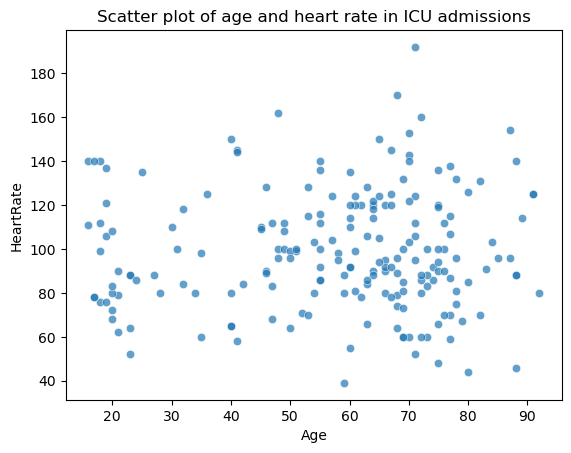

In [40]:
sns.scatterplot(x = 'Age', y = 'HeartRate', data = df, alpha = 0.7)
plt.xlabel('Age')
plt.ylabel('HeartRate')
plt.title("Scatter plot of age and heart rate in ICU admissions")
plt.show()

##### What to write about a scatter plot

- Trend (linear or non-linear)
- Outliers (if any)
- Clusters (if any)


EX: this is scatter plot to show the relation between age and heart rate, there is no clear linear or non-linear trend in the figure and also there is no point that is far away from the others, nor pattern for clustering 

#### Some bad example of the scatter plot

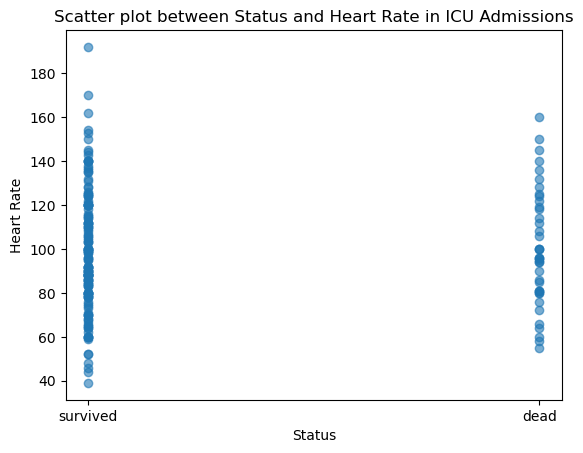

In [41]:
plt.scatter(df['Status'], df['HeartRate'], alpha = 0.6)
plt.xlabel('Status')
plt.ylabel('Heart Rate')
plt.title('Scatter plot between Status and Heart Rate in ICU Admissions')
plt.show()

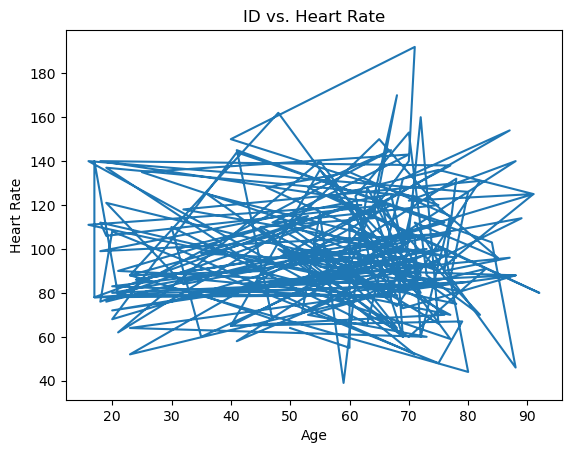

In [42]:
plt.plot(df['Age'], df['HeartRate'])
plt.xlabel('Age')
plt.ylabel('Heart Rate')
plt.title('ID vs. Heart Rate')
plt.show()

#### One categorical and one numerical: side-by-side boxplot

Other choices include side-by-side histogram and side-by-side density plot

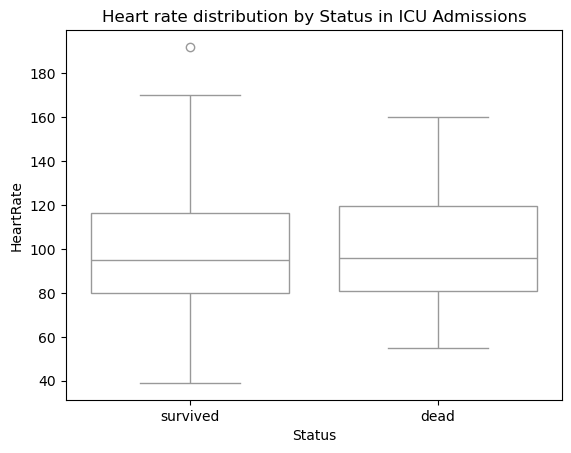

In [44]:
sns.boxplot(x ='Status', y = 'HeartRate', data = df, color = 'white')
plt.xlabel('Status')
plt.ylabel('HeartRate')
plt.title('Heart rate distribution by Status in ICU Admissions')
plt.show()

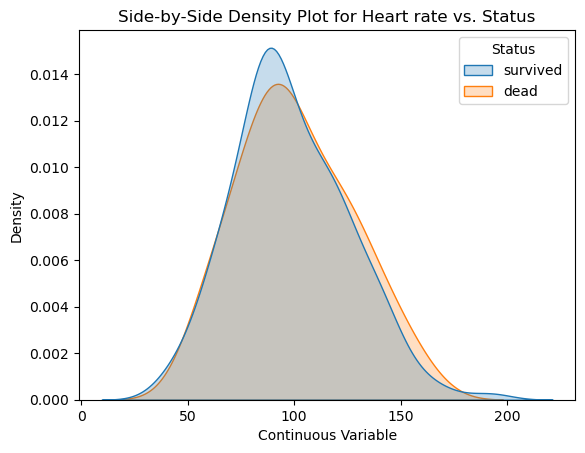

In [45]:
sns.kdeplot(data=df, x='HeartRate', hue='Status', fill=True, common_norm=False)
plt.title('Side-by-Side Density Plot for Heart rate vs. Status')
plt.xlabel('Continuous Variable')
plt.ylabel('Density')
# Show the plot
plt.show()

##### What to write about a side-by-side boxplot or density plot

- Highlight the comparision
- For boxplot, declare whether the box parts are overlapped


#### Two categorical: side-by-side bar plot

In [22]:
df['CPR'] = df['CPR'].map({1: 'yes', 0: 'no'})


In [ ]:
proportion_table = pd.crosstab(df['Status'], df['CPR'])
print(proportion_table)

CPR          no    yes
Status                
dead      0.165  0.035
survived  0.770  0.030


##### What to write about a side-by-side bar plot

- Highlight the comparision

### Figures related to statistical modeling

Visualization plays an important role in statistical modeling. We often use visualizations to assess whether the data satisfy a model’s assumptions and to evaluate how well the model fits the data. Although statistical modeling is not required in this course, the following are some general guidelines for those who are interested in exploring it further.

#### Regression models

If you choose to fit a regression model to your data—for example, a linear regression model—you are expected to check the underlying model assumptions before reporting any results. These assumptions are typically related to the distributional properties of the data and the behavior of the residuals. For a linear regression model, a formal statistical analysis usually includes the following checks:

- Distribution of the target variable: Examine whether the response variable is approximately normally distributed (e.g., using a histogram or density plot).
- Residual diagnostics: Assess whether the residuals are normally distributed and randomly dispersed (e.g., residuals vs. predictor values, residuals vs. fitted values, and a Q–Q plot).
- Outlier and influence detection: Use leverage and Cook’s distance plots to identify potential outliers or influential observations.

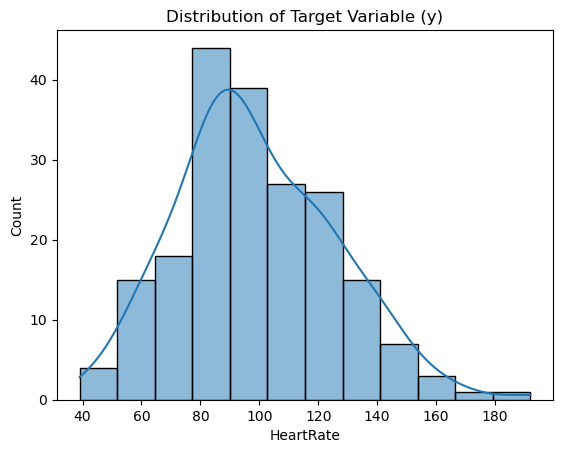

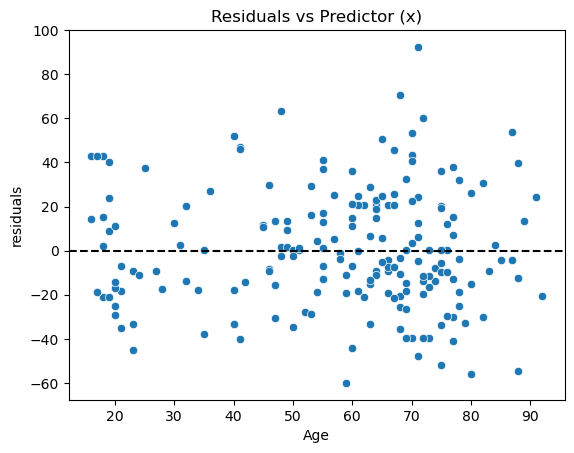

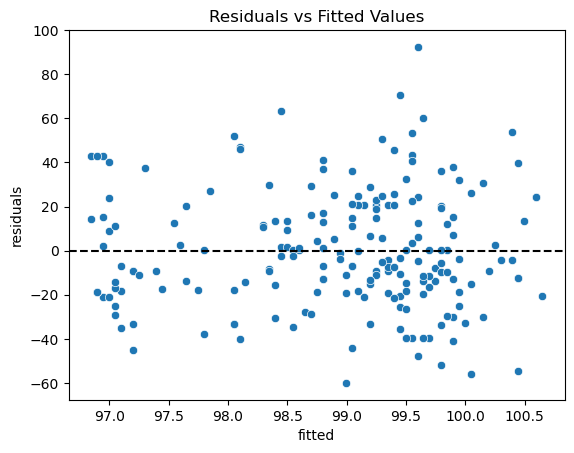

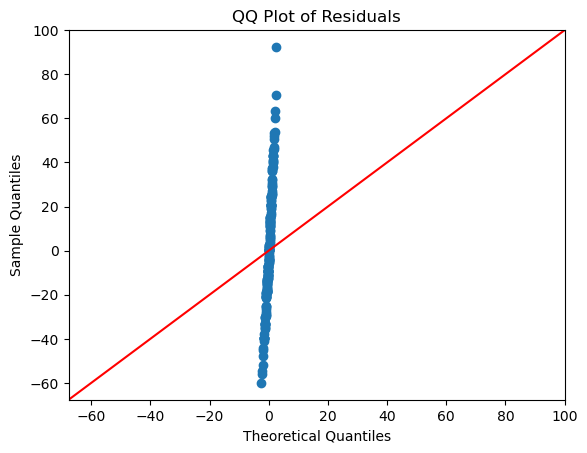

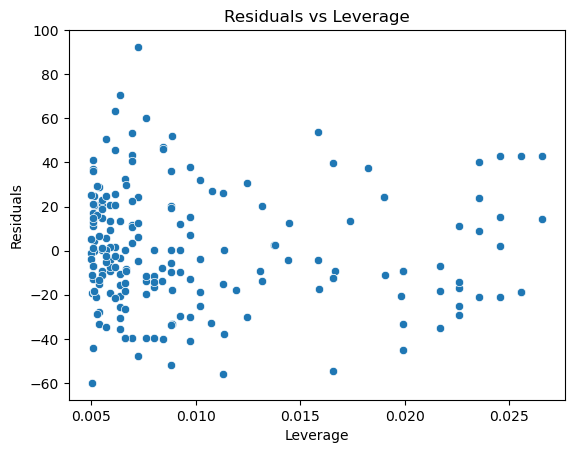

NameError: name 'np' is not defined

In [43]:
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence

# -------------------------
# Fit linear regression
# -------------------------
X = sm.add_constant(df["Age"])
model = sm.OLS(df["HeartRate"], X).fit()

df["fitted"] = model.fittedvalues
df["residuals"] = model.resid

# -------------------------
# 1. Target variable distribution
# -------------------------
sns.histplot(df["HeartRate"], kde=True)
plt.title("Distribution of Target Variable (y)")
plt.show()

# -------------------------
# 2. Residual diagnostics
# -------------------------

# Residuals vs x
sns.scatterplot(x=df["Age"], y=df["residuals"])
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals vs Predictor (x)")
plt.show()

# Residuals vs fitted values
sns.scatterplot(x=df["fitted"], y=df["residuals"])
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.show()

# QQ plot of residuals
qqplot(df["residuals"], line="45")
plt.title("QQ Plot of Residuals")
plt.show()

# -------------------------
# 3. Leverage & Cook's Distance
# -------------------------
influence = OLSInfluence(model)

# Leverage vs residuals
sns.scatterplot(x=influence.hat_matrix_diag, y=df["residuals"])
plt.xlabel("Leverage")
plt.ylabel("Residuals")
plt.title("Residuals vs Leverage")
plt.show()

# Cook's distance
sns.scatterplot(
    x=np.arange(len(df)),
    y=influence.cooks_distance[0]
)
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")
plt.show()


#### Tree models
Tree-based models are another family of models that are closely connected to visualization. Unlike linear regression, tree models do not rely on strong distributional assumptions, so visualizations are generally used to present and interpret the results, rather than to diagnose model assumptions.

- If you use a decision tree, you are expected to present a tree plot to show how the model makes decisions.
- If you use a random forest, you are expected to include a feature importance visualization to explain which variables contribute most to the model.

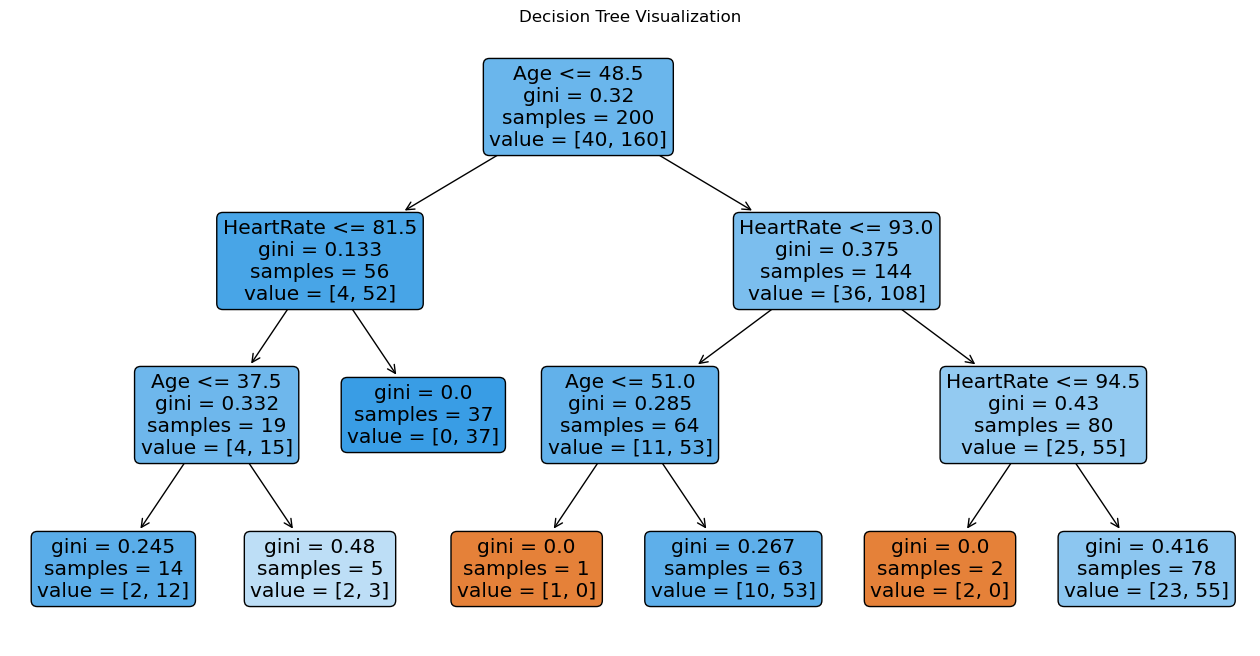

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Example dataset
X = df[["HeartRate", "Age"]]
y = df["Status"]

# Fit decision tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X, y)

# Plot decision tree
plt.figure(figsize=(16, 8))
plot_tree(
    dt,
    feature_names=X.columns,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization")
plt.show()


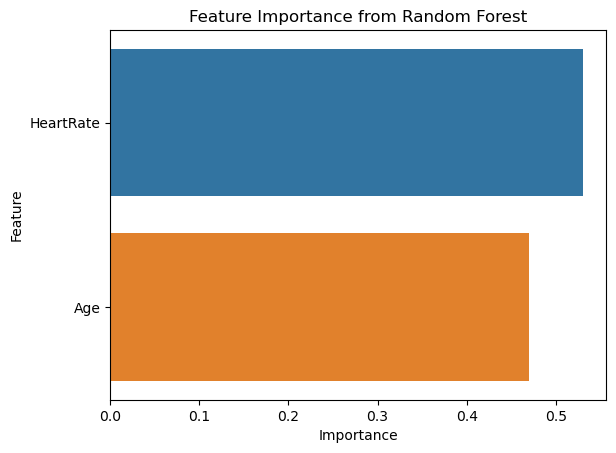

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Fit random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extract feature importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

# Plot feature importance
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


#### Clustering models

If there is no target variable, the model is considered unsupervised. Clustering is one of the most common types of unsupervised modeling. Depending on the clustering method used, there are different expectations for visualization:

- Hierarchical clustering: Include a dendrogram to show the hierarchical structure of the clusters.
- K-means clustering: Include a plot used to select the number of clusters (e.g., an elbow plot) as well as a two-dimensional PCA plot to visualize the resulting clustering patterns.

### In-class activities: Try to make data visualizaiton by yourself

See the data with about Titanic. Try to make three data visualization to study how other features affect the "survived" (whether the person survived from the Titanic disaster). Once you finish, show your figures to the neighbors and describe the figures to them. 

Note: This is not a complete data, feel free to remove the missing values(or do any other data pre-processing) before you making the plots. 

In [ ]:
titanic_data = sns.load_dataset('titanic')
print(titanic_data.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


#### Other options

Matplotlib and seaborn also allow you to do some level of customization. 
Read the documents here to change color/size/shape for your plot. Save your work to submit to the quiz later. 

https://matplotlib.org/2.1.1/api/_as_gen/matplotlib.pyplot.plot.html


### Conclusion

- One categorical: bar plot
- One continous: histogram/density plot/boxplot
- Two continous: scatter plot
- One categorical and one continous: side-by-side boxplot
- Two categorical: side-by-side bar plot

But, wait, why?

In-class activities: discuss what other options you want to have for your plots?